# LOADING LIBRARIES

In [1]:
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from sklearn.model_selection import train_test_split

from src.dataset import load_preprocessed_dataset, get_data_loaders
from src.plotting import plt_sample, plt_pred

# LOADING DATASET

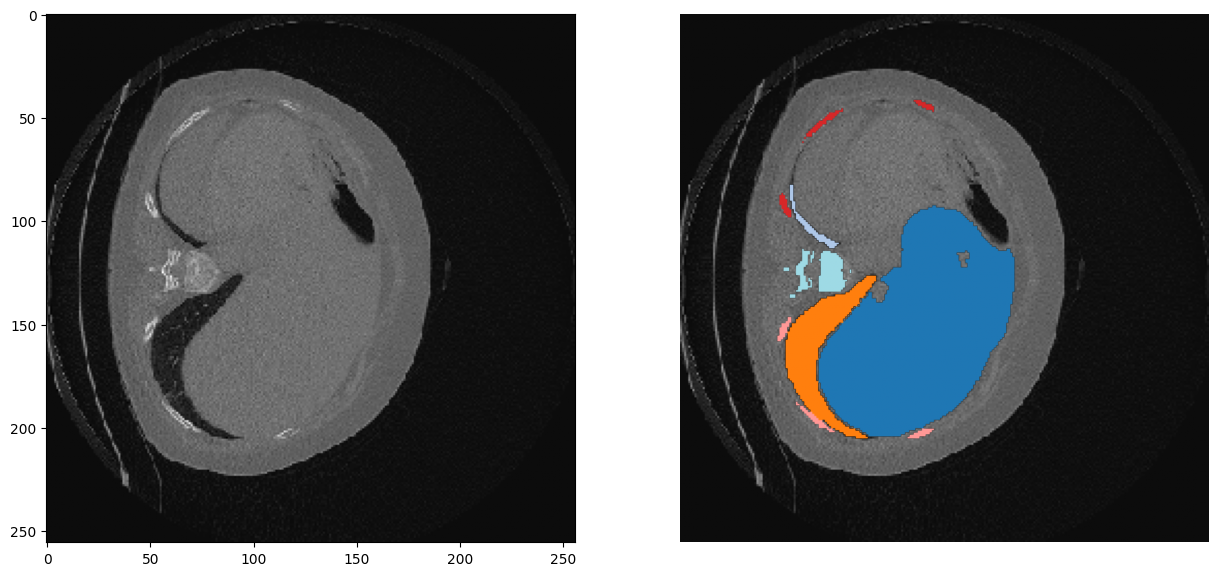

In [2]:
x_train, y_train, x_test = load_preprocessed_dataset()
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train,
    y_train,
    test_size=0.1,
    random_state=1,
)

SAMPLE_IDX = 0
plt_sample(
    x_train[SAMPLE_IDX].squeeze(),
    y_train[SAMPLE_IDX].squeeze().to(dtype=torch.float32),
)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Swin-UNET

In [5]:
import os
from typing import Callable, Dict

from torch import nn, Tensor
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

from src.plotting import plt_pred
from src.metrics import dice_pandas


def train_unet(
        model: nn.Module,
        device: torch.device,
        train_loader: DataLoader,
        valid_loader: DataLoader,
        labels_weights: Tensor,
        n_epochs: int,
        n_classes: int,
        criterion: Callable[[Tensor, Tensor], Dict[str, Tensor]],
        save_checkpoint: bool=True,
        plt_preds: bool=True
    ):

    torch.backends.cuda.matmul.fp32_precision = 'ieee'
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    labels_weights = labels_weights.to(device)

    model = model.to(device)

    for epoch in tqdm(range(n_epochs)):
        # Train
        model.train()
        train_loss = 0
        for (image, y_true) in train_loader:
            image = image.to(device=device)
            y_true = y_true.to(device=device)
            optimizer.zero_grad()
            with torch.autocast(device_type=device.type, dtype=torch.bfloat16):
                y_pred_logits = model(image)
                losses = criterion(y_pred_logits, y_true)
                loss = losses["average_loss"]
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_loss += loss.item()
        # Evaluate
        with torch.no_grad() :
            model.eval()
            test_loss = 0
            predictions = []
            true_masks = []

            for (image, y_true) in valid_loader:
                true_masks.append(y_true.cpu().numpy().squeeze())
                image = image.to(device=device)
                y_true = y_true.to(device=device)

                y_pred_logits = model(image)

                losses = criterion(y_pred_logits, y_true)
                loss = losses["average_loss"]
                test_loss += loss.item()

                pred = torch.argmax(y_pred_logits, dim=1)
                predictions.append(pred.squeeze().cpu().numpy())

            predictions = pd.DataFrame(np.array(predictions).reshape((-1, 256*256)))
            valid = pd.DataFrame(np.array(true_masks).reshape((-1, 256*256)))
            score = dice_pandas(valid, predictions, n_classes)

        print(f"Epoch : {epoch} \t Training Loss : {train_loss / len(train_loader):.3f} \t Test Loss : {test_loss / len(valid_loader):.3f} \t Score: {score:.3f}")

        if save_checkpoint:
            os.makedirs("checkpoints", exist_ok=True)
            state_dict = model.state_dict()
            torch.save(state_dict, f'checkpoints/checkpoint_epoch{epoch}.pth')
        if plt_preds:
            plt_pred(model, 100, x_train, y_train)
            plt_pred(model, 7, x_valid, y_valid)
            plt_pred(model, 20, x_test)

In [10]:
from monai.networks.nets import SwinUNETR

from src.metrics import get_class_weights, SegmentationLoss

NUM_CLASSES = 55
def mk_model() -> nn.Module:
    return SwinUNETR(
        in_channels=1,
        out_channels=NUM_CLASSES,
        feature_size=48,
        spatial_dims=2,
        use_v2=True,
    ).to(device)

model = mk_model()

train_loader, valid_loader = get_data_loaders(
    x_train,
    y_train,
    x_valid,
    y_valid,
    batch_size=1,
)
class_weights = get_class_weights().to(device)
cirterion = SegmentationLoss(class_weights)
N_EPOCHS = 1
train_unet(
    model,
    device,
    train_loader,
    valid_loader,
    class_weights,
    N_EPOCHS,
    NUM_CLASSES,
    cirterion,
    save_checkpoint=True,
    plt_preds=False,
)

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch : 0 	 Training Loss : 2.023 	 Test Loss : 1.682 	 Score: 0.018


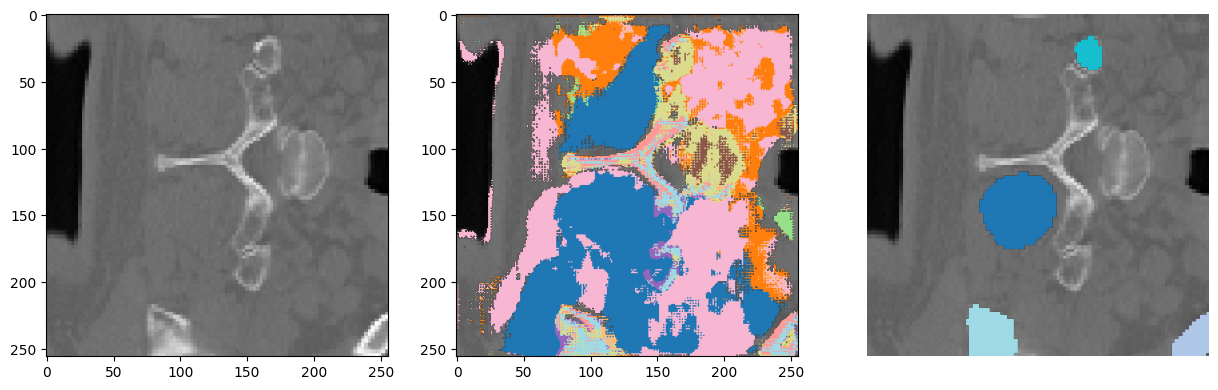

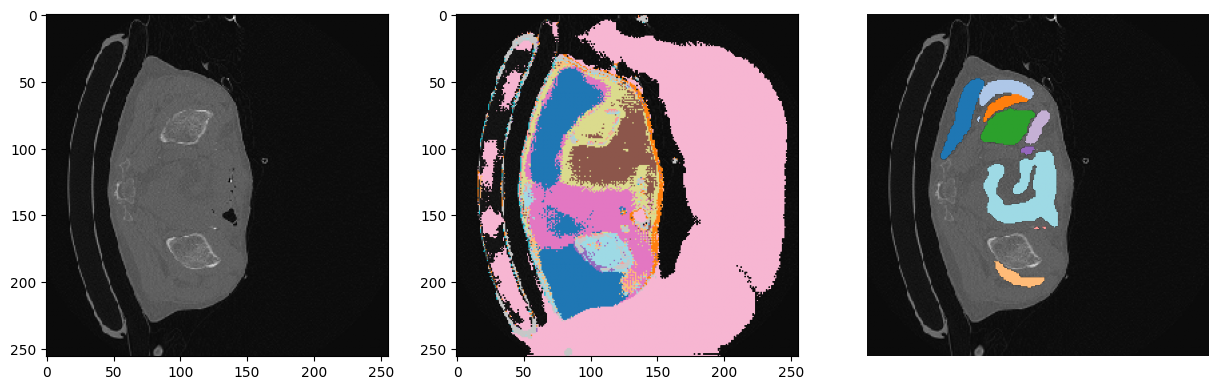

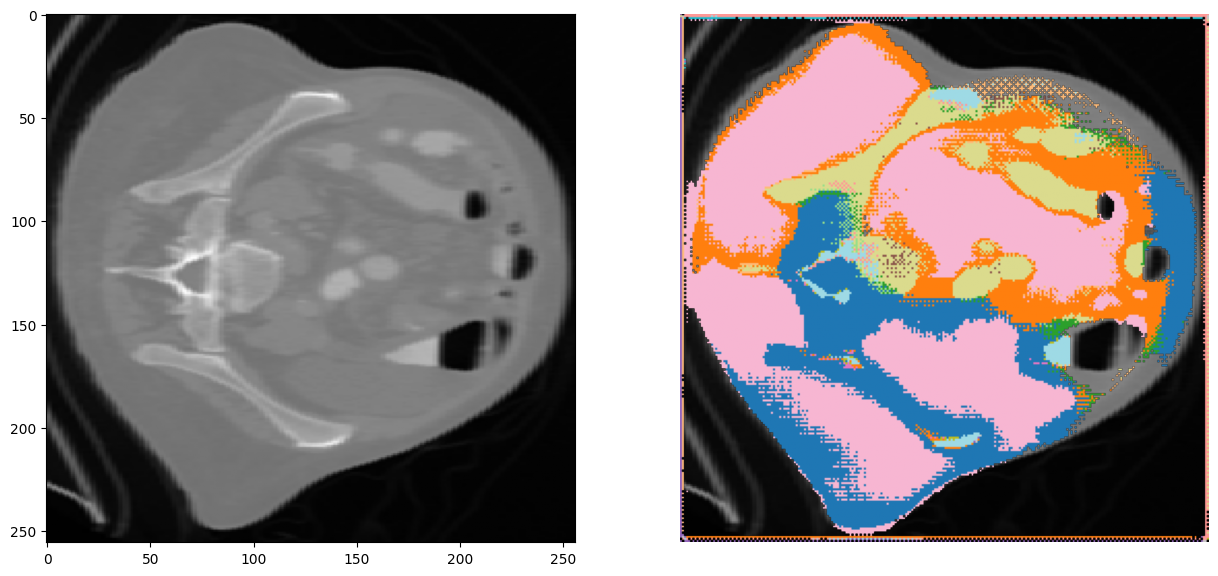

In [19]:
model_weights = torch.load(
    f'checkpoints/checkpoint_epoch{N_EPOCHS - 1}.pth',
    weights_only=True,
)
test_model = mk_model().eval()
test_model.load_state_dict(model_weights)
plt_pred(test_model, 100, x_train, y_train)
plt_pred(test_model, 6, x_valid, y_valid)
plt_pred(test_model, 6, x_test)

In [ ]:
test_loader = DataLoader(x_test, batch_size=1, shuffle=False)

predictions = []

for image in test_loader :
    image = image.to(device=device)

    y_pred_logits = test_model(image)

    pred = torch.argmax(y_pred_logits, dim=1)
    predictions.append(pred.cpu().numpy())

predictions = np.array(predictions)
print("n unique values:", len(np.unique(predictions)))
df = pd.DataFrame(predictions.reshape((predictions.shape[0], -1))).T

df.index = [f"Pixel {i}" for i in df.index]

df.columns = [f"{col}.png" for col in df.columns]

df.to_csv("submission.csv")